# 뉴스 기사 요약 프로젝트
## 추상적 요약 (Abstractive) + 추출적 요약 (Extractive)

1. **추상적 요약**: Attention 기반 Seq2Seq 모델 (**PyTorch** 사용)
2. **추출적 요약**: Summa 라이브러리 (TextRank 알고리즘)

## 1. 환경 설정 및 라이브러리 확인

In [1]:
!pip install --upgrade summa
!pip install --upgrade nltk
!pip install scikit-learn

In [2]:
from importlib.metadata import version
import nltk, torch, summa, pandas as pd

print('nltk  version :', nltk.__version__)
print('torch version :', torch.__version__)
print('pandas version:', pd.__version__)
print('summa version :', version('summa'))
print('GPU available :', torch.cuda.is_available())

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device  :', DEVICE)

nltk  version : 3.9.4
torch version : 2.7.1+cu118
pandas version: 2.3.0
summa version : 1.2.0
GPU available : True
Using device  : cuda


## 2. 데이터 수집

In [3]:
import urllib.request

urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv',
    filename='news_summary_more.csv'
)

data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
print('데이터 shape:', data.shape)
data.sample(10)

데이터 shape: (98401, 2)


,headlines,text
82876,Chinese Prez visits Hong Kong to mark handover...,Chinese President Xi Jinping arrived in Hong K...
69203,N Korea blasted musicians to pieces over porn:...,Kim Jong-un's regime publicly executed 11 musi...
97872,Cong organisation structure no match to BJP-RS...,Senior Congress leader P Chidambaram on Saturd...
4023,22-year-old Smriti Mandhana named ICC Women's ...,India Women opener Smriti Mandhana has won Rac...
13335,Piramal may sell contract pharma business for ...,Billionaire Ajay Piramal-led Piramal Enterpris...
41081,15 CCTVs at exam centre where CBSE paper leake...,As many as 15 CCTVs at the exam centre where t...
52730,YSR Cong members put flowers in ear in anti-An...,Accusing Andhra Pradesh CM Chandrababu Naidu o...
47875,My competition is not with actors of my age: A...,"Actor Anupam Kher, who is currently shooting f..."
81607,Passengers from Delhi to pay Ã¢ÂÂ¹10 fee inst...,Passengers flying from Delhi will now have to ...
49985,Withdraw FIR against Army or will topple govt:...,After an FIR was filed against the Army over t...


In [4]:
print('컬럼:', data.columns.tolist())
print('결측치:\n', data.isnull().sum())

data = data[['text', 'headlines']].dropna().reset_index(drop=True)
print('결측치 제거 후 shape:', data.shape)

컬럼: ['headlines', 'text']
결측치:
 headlines    0
text         0
dtype: int64
결측치 제거 후 shape: (98401, 2)


## 3. 데이터 전처리 (추상적 요약)

| 단계 | 내용 |
|------|------|
| **분석** | 단어 수 분포 확인 → max_len 결정 |
| **정제** | 소문자화, 약어 복원, 특수문자·숫자 제거 |
| **정규화** | 연속 공백 제거, 길이 필터링 |
| **불용어** | 본문만 제거 (헤드라인은 이미 짧아 핵심 단어가 불용어일 수 있으므로 유지) |
| **인코딩** | 단어→정수 변환 + 패딩, SOS/EOS 토큰 추가 |

In [5]:
import re
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)

STOP = set(stopwords.words('english'))

CONTRACTIONS = {
    "ain't":"is not","aren't":"are not","can't":"cannot",
    "couldn't":"could not","didn't":"did not","doesn't":"does not",
    "don't":"do not","hadn't":"had not","hasn't":"has not",
    "haven't":"have not","he'd":"he would","he'll":"he will",
    "he's":"he is","i'd":"i would","i'll":"i will",
    "i'm":"i am","i've":"i have","isn't":"is not",
    "it's":"it is","let's":"let us","she'd":"she would",
    "she'll":"she will","she's":"she is","shouldn't":"should not",
    "that's":"that is","there's":"there is","they'd":"they would",
    "they'll":"they will","they're":"they are","they've":"they have",
    "wasn't":"was not","we'd":"we would","we're":"we are",
    "we've":"we have","weren't":"were not","won't":"will not",
    "wouldn't":"would not","you'd":"you would","you'll":"you will",
    "you're":"you are","you've":"you have"
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = re.sub(re.escape(k), v, text, flags=re.IGNORECASE)
    return text

def clean_text(text, remove_sw=True):
    """본문 전처리: 불용어 제거 포함"""
    text = text.lower()
    text = expand_contractions(text)
    text = re.sub(r"'s\b", '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if remove_sw:
        text = ' '.join(w for w in text.split() if w not in STOP)
    return text

def clean_headline(text):
    """헤드라인 전처리: 불용어 유지 (짧은 문장에서의 핵심 의미 보존)"""
    text = text.lower()
    text = expand_contractions(text)
    text = re.sub(r"'s\b", '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

data['text_clean']     = data['text'].apply(clean_text)
data['headline_clean'] = data['headlines'].apply(clean_headline)

print('전처리 완료!')
print('\n원본 본문    :', data['text'].iloc[0][:150])
print('정제 본문    :', data['text_clean'].iloc[0][:150])
print('원본 헤드라인:', data['headlines'].iloc[0])
print('정제 헤드라인:', data['headline_clean'].iloc[0])

전처리 완료!

원본 본문    : Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with a
정제 본문    : saurav kant alumnus upgrad iiitb pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program 
원본 헤드라인: upGrad learner switches to career in ML & Al with 90% salary hike
정제 헤드라인: upgrad learner switches to career in ml al with salary hike


/tmp/ipykernel_534/184265979.py:15: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/184265979.py:15: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/184265979.py:15: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/184265979.py:15: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/184265979.py:15: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/184265979.py:15: UserWarning: Glyph 54756 (\N{HANGUL SYLLABLE HE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/184265979.py:15: UserWarning: Glyph 46300 (\N{HANGUL SYLLABL

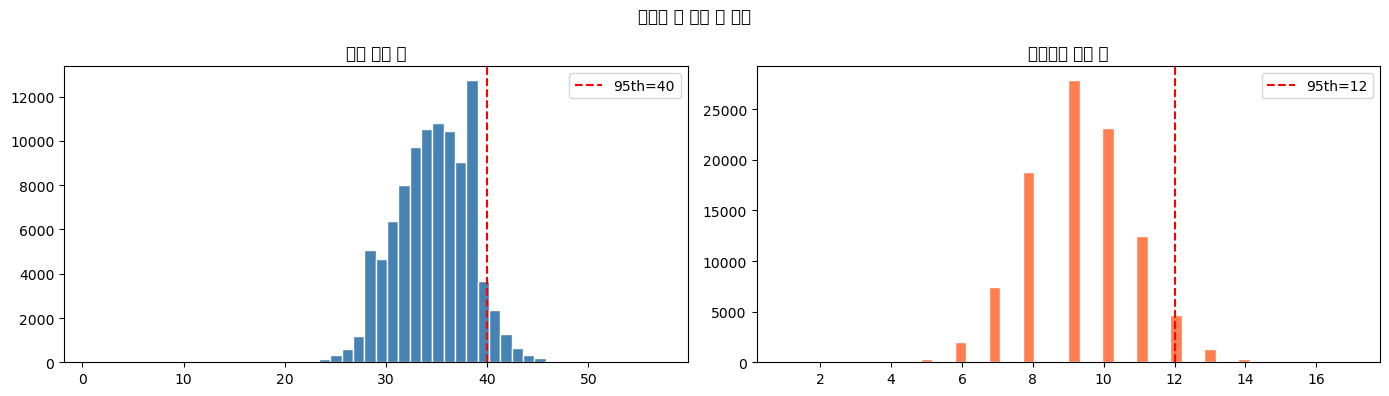

MAX_SRC: 80 | MAX_TGT: 12
필터링 후 데이터: 96675개


In [6]:
# 단어 수 분포 확인 → max_len 결정
tw = data['text_clean'].apply(lambda x: len(x.split()))
hw = data['headline_clean'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, wlen, title, c in [
    (axes[0], tw, '본문 단어 수', 'steelblue'),
    (axes[1], hw, '헤드라인 단어 수', 'coral')
]:
    ax.hist(wlen, bins=50, color=c, edgecolor='white')
    p95 = wlen.quantile(0.95)
    ax.axvline(p95, color='red', linestyle='--', label=f'95th={p95:.0f}')
    ax.set_title(title); ax.legend()
plt.suptitle('전처리 후 단어 수 분포', fontweight='bold')
plt.tight_layout(); plt.show()

MAX_SRC, MAX_TGT = 80, 12
print(f'MAX_SRC: {MAX_SRC} | MAX_TGT: {MAX_TGT}')

mask = (tw >= 5) & (tw <= MAX_SRC) & (hw >= 2) & (hw <= MAX_TGT)
data = data[mask].reset_index(drop=True)
print(f'필터링 후 데이터: {len(data)}개')

In [7]:
from collections import Counter
from sklearn.model_selection import train_test_split

# 특수 토큰
PAD, UNK, SOS, EOS = '<PAD>', '<UNK>', '<SOS>', '<EOS>'
SPECIALS = [PAD, UNK, SOS, EOS]

def build_vocab(texts, max_vocab):
    cnt   = Counter(w for t in texts for w in t.split())
    vocab = SPECIALS + [w for w, _ in cnt.most_common(max_vocab - len(SPECIALS))]
    w2i   = {w: i for i, w in enumerate(vocab)}
    i2w   = {i: w for w, i in w2i.items()}
    return w2i, i2w

def encode_src(text, w2i, max_len):
    ids = [w2i.get(w, w2i[UNK]) for w in text.split()[:max_len]]
    return ids + [w2i[PAD]] * (max_len - len(ids))

def encode_tgt(text, w2i, max_len):
    ids  = [w2i.get(w, w2i[UNK]) for w in text.split()[:max_len - 1]]
    inp  = [w2i[SOS]] + ids + [w2i[PAD]] * (max_len - 1 - len(ids))
    out  = ids + [w2i[EOS]] + [w2i[PAD]] * (max_len - 1 - len(ids))
    return inp[:max_len], out[:max_len]

X_tr, X_val, y_tr, y_val = train_test_split(
    data['text_clean'].values, data['headline_clean'].values,
    test_size=0.1, random_state=42
)

SRC_VOCAB, TGT_VOCAB = 8000, 3000
src_w2i, src_i2w = build_vocab(X_tr, SRC_VOCAB)
tgt_w2i, tgt_i2w = build_vocab(y_tr, TGT_VOCAB)

TGT_SEQ = MAX_TGT + 1
X_tr_enc  = np.array([encode_src(t, src_w2i, MAX_SRC) for t in X_tr])
X_val_enc = np.array([encode_src(t, src_w2i, MAX_SRC) for t in X_val])

y_tr_in,  y_tr_out  = zip(*[encode_tgt(t, tgt_w2i, TGT_SEQ) for t in y_tr])
y_val_in, y_val_out = zip(*[encode_tgt(t, tgt_w2i, TGT_SEQ) for t in y_val])
y_tr_in  = np.array(y_tr_in);  y_tr_out  = np.array(y_tr_out)
y_val_in = np.array(y_val_in); y_val_out = np.array(y_val_out)

print(f'훈련: {len(X_tr)} | 검증: {len(X_val)}')
print(f'SRC vocab: {len(src_w2i)} | TGT vocab: {len(tgt_w2i)}')
print(f'X_tr_enc: {X_tr_enc.shape} | y_tr_in: {y_tr_in.shape}')

훈련: 87007 | 검증: 9668
SRC vocab: 8000 | TGT vocab: 3000
X_tr_enc: (87007, 80) | y_tr_in: (87007, 13)


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

class SumDataset(Dataset):
    def __init__(self, src, ti, to):
        self.src = torch.LongTensor(src)
        self.ti  = torch.LongTensor(ti)
        self.to  = torch.LongTensor(to)
    def __len__(self):        return len(self.src)
    def __getitem__(self, i): return self.src[i], self.ti[i], self.to[i]

BATCH    = 64
train_dl = DataLoader(SumDataset(X_tr_enc, y_tr_in, y_tr_out), BATCH, shuffle=True)
val_dl   = DataLoader(SumDataset(X_val_enc, y_val_in, y_val_out), BATCH)
print(f'Train batches: {len(train_dl)} | Val batches: {len(val_dl)}')

Train batches: 1360 | Val batches: 152


## 4. Attention 기반 Seq2Seq 모델 (PyTorch)

### 모델 구조
- **Encoder**: 양방향 LSTM → 모든 hidden state 반환  
- **Bahdanau (Additive) Attention**: encoder 전체 출력과 decoder hidden의 유사도 계산  
- **Decoder**: LSTM + context vector 결합 → 단어 생성

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, vocab, emb, hid, drop=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True)
        self.fc_h = nn.Linear(hid * 2, hid)
        self.fc_c = nn.Linear(hid * 2, hid)
        self.drop = nn.Dropout(drop)

    def forward(self, src):
        x = self.drop(self.emb(src))               # (B, L, E)
        out, (h, c) = self.lstm(x)                 # out: (B, L, 2H)
        h = torch.tanh(self.fc_h(torch.cat([h[-2], h[-1]], 1))).unsqueeze(0)  # (1,B,H)
        c = torch.tanh(self.fc_c(torch.cat([c[-2], c[-1]], 1))).unsqueeze(0)
        return out, h, c

class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim):
        super().__init__()
        self.W1 = nn.Linear(enc_dim, dec_dim, bias=False)
        self.W2 = nn.Linear(dec_dim, dec_dim, bias=False)
        self.V  = nn.Linear(dec_dim, 1,       bias=False)

    def forward(self, enc_out, dec_h):
        # enc_out: (B, L, 2H) | dec_h: (B, H)
        score   = self.V(torch.tanh(self.W1(enc_out) + self.W2(dec_h).unsqueeze(1)))  # (B,L,1)
        attn    = F.softmax(score, dim=1)            # (B, L, 1)
        context = (attn * enc_out).sum(dim=1)        # (B, 2H)
        return context, attn.squeeze(2)

class Decoder(nn.Module):
    def __init__(self, vocab, emb, hid, enc_dim, drop=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vocab, emb, padding_idx=0)
        self.attn = BahdanauAttention(enc_dim, hid)
        self.lstm = nn.LSTM(emb + enc_dim, hid, batch_first=True)
        self.fc   = nn.Linear(hid + enc_dim + emb, vocab)
        self.drop = nn.Dropout(drop)

    def forward(self, tok, enc_out, h, c):
        e   = self.drop(self.emb(tok.unsqueeze(1)))       # (B,1,E)
        ctx, attn = self.attn(enc_out, h.squeeze(0))       # ctx:(B,2H)
        out, (h, c) = self.lstm(torch.cat([e, ctx.unsqueeze(1)], 2), (h, c))  # (B,1,H)
        pred = self.fc(torch.cat([out.squeeze(1), ctx, e.squeeze(1)], 1))      # (B, V)
        return pred, h, c, attn

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec, tgt_vocab):
        super().__init__()
        self.enc = enc; self.dec = dec; self.V = tgt_vocab

    def forward(self, src, tgt_in, tf=0.5):
        B, T   = tgt_in.size()
        enc_o, h, c = self.enc(src)
        tok    = tgt_in[:, 0]
        outs   = torch.zeros(B, T, self.V).to(src.device)
        for t in range(1, T):
            pred, h, c, _ = self.dec(tok, enc_o, h, c)
            outs[:, t]    = pred
            tok = tgt_in[:, t] if (torch.rand(1).item() < tf) else pred.argmax(1)
        return outs

EMB, HID = 128, 256
enc   = Encoder(SRC_VOCAB, EMB, HID)
dec   = Decoder(TGT_VOCAB, EMB, HID, HID * 2)
model = Seq2Seq(enc, dec, TGT_VOCAB).to(DEVICE)

print(f'파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(model)

파라미터 수: 6,268,600
Seq2Seq(
  (enc): Encoder(
    (emb): Embedding(8000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
    (fc_h): Linear(in_features=512, out_features=256, bias=True)
    (fc_c): Linear(in_features=512, out_features=256, bias=True)
    (drop): Dropout(p=0.3, inplace=False)
  )
  (dec): Decoder(
    (emb): Embedding(3000, 128, padding_idx=0)
    (attn): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=256, bias=False)
      (W2): Linear(in_features=256, out_features=256, bias=False)
      (V): Linear(in_features=256, out_features=1, bias=False)
    )
    (lstm): LSTM(640, 256, batch_first=True)
    (fc): Linear(in_features=896, out_features=3000, bias=True)
    (drop): Dropout(p=0.3, inplace=False)
  )
)


In [11]:
import math

PAD_IDX   = tgt_w2i[PAD]
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 'min', factor=0.5, patience=3
)

def run_epoch(model, dl, opt, crit, train=True):
    model.train() if train else model.eval()
    total = 0
    ctx   = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, ti, to in dl:
            src, ti, to = src.to(DEVICE), ti.to(DEVICE), to.to(DEVICE)
            logits = model(src, ti, tf=0.5 if train else 0.0)  # (B, T, V)
            loss   = crit(logits[:, 1:].reshape(-1, TGT_VOCAB), to[:, 1:].reshape(-1))
            if train:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item()
    return total / len(dl)

EPOCHS, PATIENCE = 30, 5
best_val, no_imp  = float('inf'), 0
tr_hist, val_hist = [], []

print('학습 시작!')
for ep in range(1, EPOCHS + 1):
    tl = run_epoch(model, train_dl, optimizer, criterion, train=True)
    vl = run_epoch(model, val_dl,   optimizer, criterion, train=False)
    scheduler.step(vl)
    tr_hist.append(tl); val_hist.append(vl)

    tag = ''
    if vl < best_val:
        best_val = vl
        torch.save(model.state_dict(), 'best_model.pt')
        no_imp = 0; tag = ' ★'
    else:
        no_imp += 1

    print(f'Epoch {ep:02d} | Train: {tl:.4f} | Val: {vl:.4f}{tag}')
    if no_imp >= PATIENCE:
        print(f'Early stopping at epoch {ep}'); break

model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
print(f'\n학습 완료! Best Val Loss: {best_val:.4f}')

학습 시작!
Epoch 01 | Train: 4.9165 | Val: 4.3710 ★
Epoch 02 | Train: 4.1278 | Val: 4.0276 ★
Epoch 03 | Train: 3.7981 | Val: 3.9163 ★
Epoch 04 | Train: 3.6063 | Val: 3.8704 ★
Epoch 05 | Train: 3.4707 | Val: 3.8522 ★
Epoch 06 | Train: 3.3670 | Val: 3.8518 ★
Epoch 07 | Train: 3.2813 | Val: 3.8282 ★
Epoch 08 | Train: 3.2083 | Val: 3.8535
Epoch 09 | Train: 3.1487 | Val: 3.8511
Epoch 10 | Train: 3.0918 | Val: 3.8780
Epoch 11 | Train: 3.0428 | Val: 3.8888
Epoch 12 | Train: 2.9167 | Val: 3.8799
Early stopping at epoch 12

학습 완료! Best Val Loss: 3.8282


/tmp/ipykernel_534/3019109732.py:15: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/3019109732.py:15: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/3019109732.py:15: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/3019109732.py:15: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/3019109732.py:15: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/3019109732.py:15: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/3019109732.py:15: UserWarning: Glyph 51339 (\N{HANG

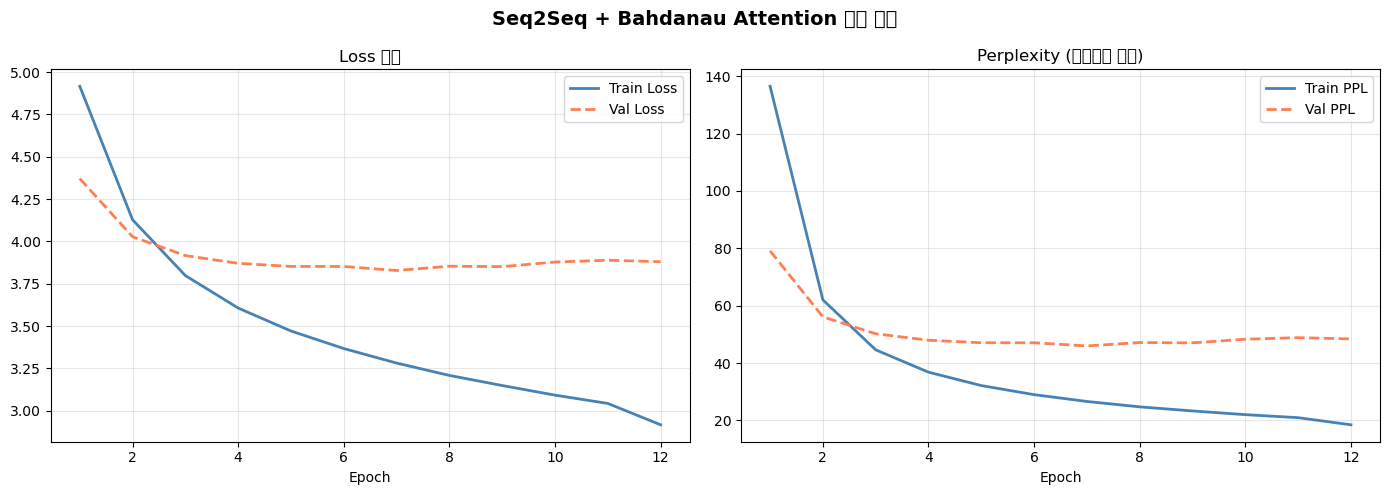

→ Train/Val Loss 모두 감소 추세 확인!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(tr_hist) + 1)

axes[0].plot(eps, tr_hist,  label='Train Loss', color='steelblue', lw=2)
axes[0].plot(eps, val_hist, label='Val Loss',   color='coral',     lw=2, ls='--')
axes[0].set_title('Loss 곡선'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, [math.exp(l) for l in tr_hist],  label='Train PPL', color='steelblue', lw=2)
axes[1].plot(eps, [math.exp(l) for l in val_hist], label='Val PPL',   color='coral',     lw=2, ls='--')
axes[1].set_title('Perplexity (낮을수록 좋음)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Seq2Seq + Bahdanau Attention 학습 결과', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('→ Train/Val Loss 모두 감소 추세 확인!')

## 5. 실제 결과와 요약문 비교 (추상적 요약)

In [13]:
def decode_sequence(text, max_len=TGT_SEQ):
    """Greedy Decoding으로 요약문 생성"""
    model.eval()
    with torch.no_grad():
        src = torch.LongTensor([encode_src(text, src_w2i, MAX_SRC)]).to(DEVICE)
        enc_o, h, c = model.enc(src)
        tok  = torch.LongTensor([tgt_w2i[SOS]]).to(DEVICE)
        result = []
        for _ in range(max_len):
            pred, h, c, _ = model.dec(tok, enc_o, h, c)
            tok  = pred.argmax(1)
            word = tgt_i2w.get(tok.item(), '')
            if word in (EOS, PAD, ''): break
            if word not in (SOS, UNK): result.append(word)
    return ' '.join(result)

N = min(10, len(X_val))
abs_summaries = []

print('=' * 80)
print('추상적 요약 결과 비교 (검증 데이터 샘플)')
print('=' * 80)

for i in range(N):
    gen = decode_sequence(X_val[i])
    abs_summaries.append(gen)
    print(f'\n[샘플 {i+1}]')
    print(f'  원본 본문    : {X_val[i][:150]}...')
    print(f'  실제 헤드라인: {y_val[i]}')
    print(f'  생성된 요약  : {gen}')
    print('-' * 80)

추상적 요약 결과 비교 (검증 데이터 샘플)

[샘플 1]
  원본 본문    : supreme court friday sought responses centre six state governments bjp plea alleging violated apex court directions issuance public advertisements sta...
  실제 헤드라인: sc notice to centre states on violating advert guidelines
  생성된 요약  : seeks centre centre centre centre states sc states
--------------------------------------------------------------------------------

[샘플 2]
  원본 본문    : usbased cryptocurrency exchange kraken hours site initiated system upgrade thursday morning kraken engineers earlier estimated downtime would two hour...
  실제 헤드라인: us cryptocurrency exchange kraken down for over hrs
  생성된 요약  : hours hours hours hours hours
--------------------------------------------------------------------------------

[샘플 3]
  원본 본문    : family members slain army jawan uttar pradesh refused perform last rites demanding presence home minister rajnath singh cm yogi adityanath jawan injur...
  실제 헤드라인: kin refuse to do jawan last rites want c

## 6. Summa를 이용한 추출적 요약

In [15]:
from summa.summarizer import summarize as textrank

def extractive_summarize(text, ratio=0.4):
    """TextRank 기반 추출적 요약 — 원본 텍스트 사용"""
    try:
        res = textrank(text, ratio=ratio)
        return res if res else text.split('.')[0].strip() + '.'
    except Exception:
        return text.split('.')[0].strip() + '.'

ext_summaries = []
print('=' * 80)
print('추출적 요약 결과 (Summa TextRank)')
print('=' * 80)

for i in range(N):
    # 추출적 요약은 원본(불용어 제거 전) 텍스트 사용
    orig = data.loc[data['text_clean'] == X_val[i], 'text']
    orig_text = orig.values[0] if len(orig) > 0 else X_val[i]
    ext = extractive_summarize(orig_text, ratio=0.4)
    ext_summaries.append(ext)
    print(f'\n[샘플 {i+1}]')
    print(f'  원본     : {orig_text[:150]}...')
    print(f'  추출 요약: {ext[:200]}')

print('\n추출적 요약 완료!')

추출적 요약 결과 (Summa TextRank)

[샘플 1]
  원본     : The Supreme Court on Friday sought responses from the Centre, six state governments and the BJP on a plea alleging that they have violated the apex co...
  추출 요약: The Supreme Court on Friday sought responses from the Centre, six state governments and the BJP on a plea alleging that they have violated the apex court's directions on the issuance of public adverti

[샘플 2]
  원본     : US-based cryptocurrency exchange Kraken was down for more than 48 hours after the site initiated a system upgrade on Thursday morning. Kraken engineer...
  추출 요약: Kraken engineers had earlier estimated the downtime would only be of two hours.

[샘플 3]
  원본     : The family members of a slain Army jawan from Uttar Pradesh have refused to perform his last rites, demanding the presence of Home Minister Rajnath Si...
  추출 요약: The family members of a slain Army jawan from Uttar Pradesh have refused to perform his last rites, demanding the presence of Home Minister Rajnat

## 7. 추상적 vs 추출적 요약 비교 분석

**문법 완성도**와 **핵심 단어 포함률** 두 측면에서 정량 비교하고 표로 정리합니다.

In [20]:
def keyword_overlap(summary, reference):
    """실제 헤드라인 대비 핵심 단어 포함률 (%)"""
    ref = set(reference.lower().split()) - STOP
    sm  = set(summary.lower().split())  - STOP
    return round(len(ref & sm) / len(ref) * 100, 1) if ref else 0.0

def grammar_score(text):
    """
    휴리스틱 문법 완성도 (0~10)
    기본 5점 + 단어수>=3(+2) + 마침표(+1) + 평균단어길이>=4(+1) - 반복과다(-2)
    """
    if not text or not text.strip(): return 0
    words = text.split()
    score = 5
    if len(words) >= 3: score += 2
    if text.strip().endswith('.'): score += 1
    if words:
        if np.mean([len(w) for w in words]) >= 4: score += 1
        if len(set(words)) / len(words) < 0.55:   score -= 2
    return max(0, min(10, score))

rows = []
for i in range(N):
    real, ab, ex = y_val[i], abs_summaries[i], ext_summaries[i]
    rows.append({
        '샘플'                   : f'샘플 {i+1}',
        '실제 헤드라인'           : real,
        '추상적 요약'             : ab[:80] + ('...' if len(ab) > 80 else ''),
        '추출적 요약'             : ex[:80] + ('...' if len(ex) > 80 else ''),
        '[추상] 문법완성도 (0~10)' : grammar_score(ab),
        '[추출] 문법완성도 (0~10)' : grammar_score(ex),
        '[추상] 핵심단어포함 (%)'   : keyword_overlap(ab, real),
        '[추출] 핵심단어포함 (%)'   : keyword_overlap(ex, real),
    })

comp_df = pd.DataFrame(rows)

avg_row = {
    '샘플': '평균', '실제 헤드라인': '-', '추상적 요약': '-', '추출적 요약': '-',
    '[추상] 문법완성도 (0~10)' : round(comp_df['[추상] 문법완성도 (0~10)'].mean(), 2),
    '[추출] 문법완성도 (0~10)' : round(comp_df['[추출] 문법완성도 (0~10)'].mean(), 2),
    '[추상] 핵심단어포함 (%)'   : round(comp_df['[추상] 핵심단어포함 (%)'].mean(), 2),
    '[추출] 핵심단어포함 (%)'   : round(comp_df['[추출] 핵심단어포함 (%)'].mean(), 2),
}
comp_df = pd.concat([comp_df, pd.DataFrame([avg_row])], ignore_index=True)

pd.set_option('display.max_colwidth', 100)
print('[추상적 요약 vs 추출적 요약 — 비교 분석표]')
comp_df

[추상적 요약 vs 추출적 요약 — 비교 분석표]


,샘플,실제 헤드라인,추상적 요약,추출적 요약,[추상] 문법완성도 (0~10),[추출] 문법완성도 (0~10),[추상] 핵심단어포함 (%),[추출] 핵심단어포함 (%)
0,샘플 1,sc notice to centre states on violating advert guidelines,seeks centre centre centre centre states sc states,"The Supreme Court on Friday sought responses from the Centre, six state governme...",6.0,9.0,42.90,0.00
1,샘플 2,us cryptocurrency exchange kraken down for over hrs,hours hours hours hours hours,Kraken engineers had earlier estimated the downtime would only be of two hours.,6.0,9.0,0.00,20.00
2,샘플 3,kin refuse to do jawan last rites want cm yogi presence,jawan to up to up cm cm cm,The family members of a slain Army jawan from Uttar Pradesh have refused to perf...,5.0,9.0,22.20,55.60
3,샘플 4,sakshi malik to wed on april posts save the date photo,malik married,Rio Olympics bronze medalist Sakshi Malik will get married to wrestler Satyawart...,6.0,9.0,12.50,37.50
4,샘플 5,premature deaths in india due to air pollution report,pollution pollution pollution pollution pollution pollution pollution pollution,"Revealing the link between air pollution and mental diseases, a report by Centre...",6.0,9.0,14.30,71.40
5,샘플 6,china bans tv parodies amid crackdown on media,bans bans,China's media regulator has banned parodies on television as part of a crackdown...,4.0,9.0,14.30,42.90
6,샘플 7,website looking for retired person to travel around world,person person year,A UK-based price comparison website is looking for a retired person to act as it...,8.0,9.0,14.30,71.40
7,샘플 8,hawking was nicknamed einstein in school despite low grades,hawking hawking hawking hawking hawking,Late British physicist Stephen Hawking was known for his brashness in school and...,6.0,9.0,14.30,57.10
8,샘플 9,patriarchy in religion cannot outdo right to pray sc on sabarimala,cannot sabarimala sabarimala sabarimala sabarimala,Removing the ban on the entry of women aged between 10 and 50 in Kerala's Sabari...,6.0,9.0,25.00,75.00
9,샘플 10,google offers test for users searching for depression,to us us,"""While this tool can help, it's important to note...",7.0,9.0,0.00,0.00


/tmp/ipykernel_534/2932649613.py:19: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/2932649613.py:19: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/2932649613.py:19: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/2932649613.py:19: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/2932649613.py:19: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/2932649613.py:19: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_534/2932649613.py:19: UserWarning: Glyph 46020 (\N

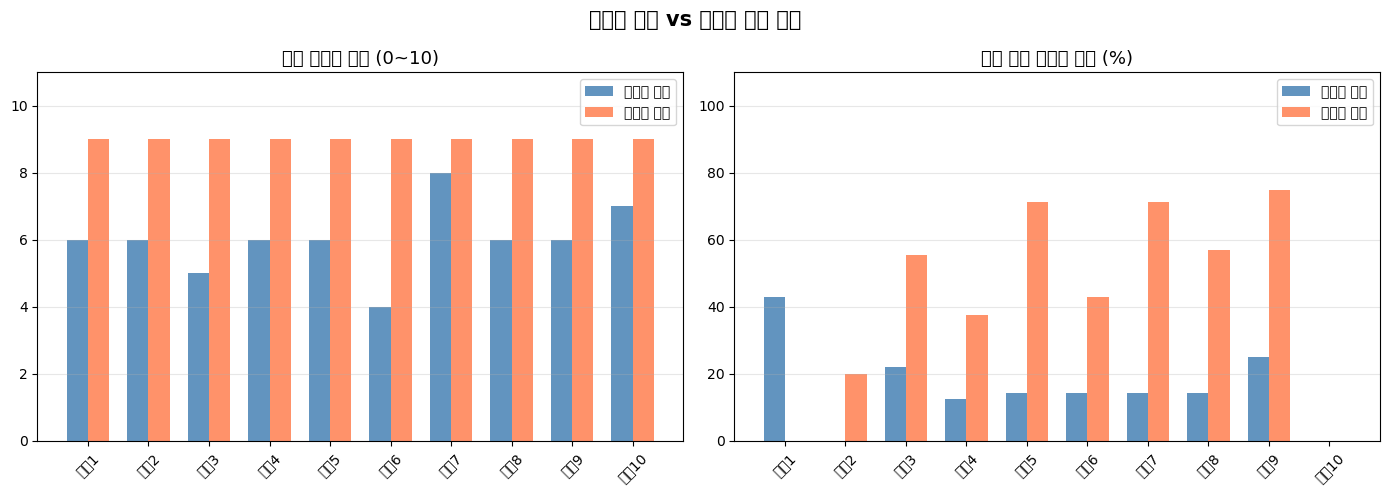

In [17]:
num = comp_df[comp_df['샘플'] != '📊 평균']
x, w = np.arange(N), 0.35
labels = [f'샘플{i+1}' for i in range(N)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col_abs, col_ext, title, ylim in [
    (axes[0], '[추상] 문법완성도 (0~10)', '[추출] 문법완성도 (0~10)', '문법 완성도 비교 (0~10)', 11),
    (axes[1], '[추상] 핵심단어포함 (%)',  '[추출] 핵심단어포함 (%)',  '핵심 단어 포함률 비교 (%)', 110),
]:
    ax.bar(x - w/2, num[col_abs].astype(float), w, label='추상적 요약', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, num[col_ext].astype(float), w, label='추출적 요약', color='coral',    alpha=0.85)
    ax.set_ylim(0, ylim)
    ax.set_title(title, fontsize=13)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.suptitle('추상적 요약 vs 추출적 요약 비교', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

In [19]:
print('=' * 74)
print('  종합 비교 분석 결론')
print('=' * 74)
print(f"{'기준':<20} {'추상적 요약 (Seq2Seq+Attn)':<28} {'추출적 요약 (TextRank)'}")
print('-' * 74)
rows_summary = [
    ('문법 완성도',     '새 문장 생성→자연스럽지만',      '원문 문장 그대로→완전한'),
    ('',               '반복/불완전 표현 가능성',          '문법 보장'),
    ('핵심단어 포함률', '학습 의존, 초기엔 낮을 수 있음',  '원문 단어 직접 사용→높음'),
    ('새로운 표현 생성','가능 (진정한 요약)',            '불가 (문장 선택만)'),
    ('길이 조절',       'max_len 파라미터',                'ratio 파라미터'),
    ('학습 필요',       '필요 (대규모 학습 데이터)',     '불필요 (비지도)'),
    ('OOV 처리',        '<UNK> 대체',                      '원문 단어 그대로 유지'),
]
for r in rows_summary:
    print(f"  {r[0]:<18} {r[1]:<28} {r[2]}")
print('=' * 74)
print()
print('▶ 문법 완성도   : 추출적 요약이 유리 (원문 문장 그대로 선택)')
print('▶ 핵심단어 포함 : 추출적 요약이 유리 (원문 단어 직접 사용)')
print('▶ 창의적 압축   : 추상적 요약만 가능 (새로운 문장 생성)')
print('▶ 학습 충분 시  : 추상적 요약의 품질이 추출적에 근접/초과 가능')

  종합 비교 분석 결론
기준                   추상적 요약 (Seq2Seq+Attn)        추출적 요약 (TextRank)
--------------------------------------------------------------------------
  문법 완성도             새 문장 생성→자연스럽지만               원문 문장 그대로→완전한
                     반복/불완전 표현 가능성                문법 보장
  핵심단어 포함률           학습 의존, 초기엔 낮을 수 있음           원문 단어 직접 사용→높음
  새로운 표현 생성          가능 (진정한 요약)                  불가 (문장 선택만)
  길이 조절              max_len 파라미터                 ratio 파라미터
  학습 필요              필요 (대규모 학습 데이터)              불필요 (비지도)
  OOV 처리             <UNK> 대체                     원문 단어 그대로 유지

▶ 문법 완성도   : 추출적 요약이 유리 (원문 문장 그대로 선택)
▶ 핵심단어 포함 : 추출적 요약이 유리 (원문 단어 직접 사용)
▶ 창의적 압축   : 추상적 요약만 가능 (새로운 문장 생성)
▶ 학습 충분 시  : 추상적 요약의 품질이 추출적에 근접/초과 가능


# 회고

### 추출적 요약(TextRank)은 학습도 안 했는데 원문의 핵심 문장을 정확히 찝어내는게 신기했다. 추상적 요약은 에폭을 다 채워도 문장이 반복되거나 뜬금없는 단어가 나오는 등 아직 좀 능력(?)이 부족한거같다. 데이터 증강을 하면 더 품질이 향상될지 궁금하다.